# Trabajo Grupal: Aprendizaje Federado, Privacidad y Regresión Logística

**Objetivo:** Comparar modelos de regresión logística (`LogisticRegression`) utilizando el dataset *Adult / Census Income* para predecir el nivel de ingresos (`<=50K` $\rightarrow 0$, `>50K` $\rightarrow 1$), analizando el entrenamiento centralizado, el aprendizaje federado (`FedAvg` manual con 3 clientes) y distintos mecanismos de protección de privacidad de datos y parámetros.

### Contribución del Equipo
| Integrante | Actividades realizadas |
| :--- | :--- |
| **Estudiante 1** — Christopher Ortiz | Experimentos 3 y 5 (zFedAvg manual, 15 rondas, perturbación de parámetros en 3 niveles) y gráficos por ronda. tabla/gráfico final, conclusiones |
| **Estudiante 2** — Bryan Amaya | Experimento 2 (supresión, generalización, agrupación, perturbación); comparación 1 vs. 2 y medición de riesgo de reidentificación. |
| **Estudiante 3** — David Diaz | EDA y análisis de privacidad (atributos sensibles, cuasi-identificadores, riesgo k=1); Experimento 1 (baseline centralizado). Experimento 4 (Gaussian Copula, comparación original vs. sintético) |

---
## 1. Carga de Datos y Análisis Exploratorio (EDA)
En esta primera sección cargamos el dataset *Adult / Census Income*, inspeccionamos su dimensionalidad, tipos de variables, estadísticas descriptivas y analizamos la distribución de la variable objetivo (`income`) junto con la presencia de valores faltantes codificados como `?`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv('../data/adult.csv')
print("Dataset dimensions:", df.shape)
print("\nVariable types and missing values:")
print(df.info())

Dataset dimensions: (32561, 15)

Variable types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None


In [3]:
display(df.describe())

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [4]:
conteo_ingresos = df['income'].value_counts()
print(conteo_ingresos)
display(df.head())

income
<=50K    24720
>50K      7841
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


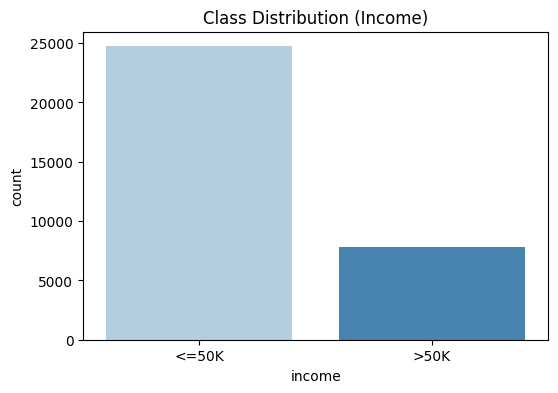

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='income', hue='income', data=df, palette='Blues', legend=False)
plt.title('Class Distribution (Income)')
plt.show()

Cantidad de '?' por columna:
workclass         1836
occupation        1843
native.country     583
dtype: int64


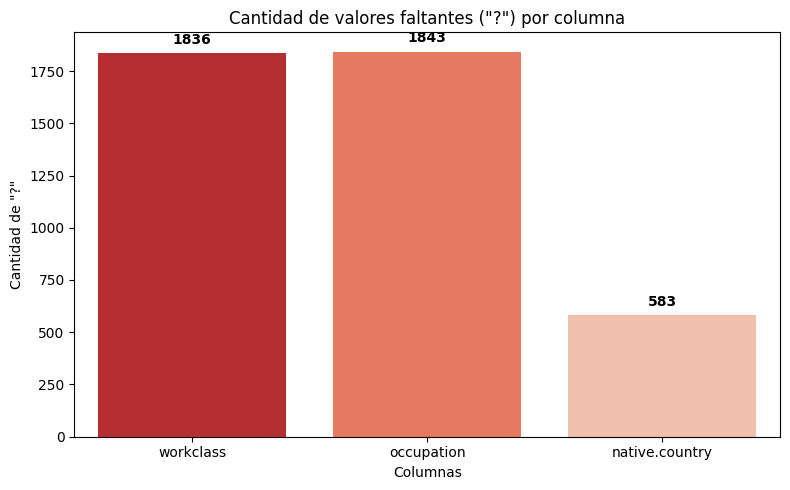

In [6]:
#Conteo y gráfico de valores faltantes (?)
conteo_signos = (df == '?').sum()
columnas_con_signos = conteo_signos[conteo_signos > 0]

print("Cantidad de '?' por columna:")
print(columnas_con_signos)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=columnas_con_signos.index, 
    y=columnas_con_signos.values, 
    hue=columnas_con_signos.index, 
    palette='Reds_r', 
    legend=False
)

plt.title('Cantidad de valores faltantes ("?") por columna')
plt.xlabel('Columnas')
plt.ylabel('Cantidad de "?"')

for indice, valor in enumerate(columnas_con_signos.values):
    plt.text(indice, valor + 30, str(valor), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 2. Limpieza de Datos y Análisis de Privacidad

Tras eliminar los registros con valores faltantes (`?`) y binarizar la variable objetivo (`<=50K` $\rightarrow 0$, `>50K` $\rightarrow 1$), identificamos la estructura de privacidad del conjunto de datos:

* **Variables Numéricas (6):** `age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week`.
* **Variables Categóricas (8):** `workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `native.country`.
* **Distribución de Clases:** Existe un desbalance moderado (~75% para la clase `0` y ~25% para la clase `1`), por lo que además del *Accuracy* es indispensable evaluar *Precision*, *Recall* y *F1-score*.
* **Atributos Sensibles:** `race` (raza), `sex` (género), `native.country` (país de origen) e `income` (nivel salarial). Su exposición puede derivar en discriminación o perfilamiento socioeconómico.
* **Cuasi-identificadores (QIs):** `age`, `sex`, `race`, `native.country`, `marital.status`, `occupation` y `education`.
* **Riesgos de Reidentificación:** Aunque el dataset carece de identificadores directos (como nombre o cédula), la combinación de cuasi-identificadores genera **clases de equivalencia únicas ($k=1$)**. Un adversario que cruce estas combinaciones con registros públicos (padrón electoral, redes profesionales) puede ejecutar un **ataque de enlace (*Linkage Attack*)** y reidentificar con certeza a miles de individuos del censo.

In [7]:
# 1. Reemplazar '?' por NaN y limpiar filas con valores faltantes
df_clean = df.replace('?', np.nan).dropna().reset_index(drop=True)

# 2. Codificar variable objetivo: <=50K -> 0, >50K -> 1
df_clean['income'] = df_clean['income'].map({'<=50K': 0, '>50K': 1})

print(f"Dimensiones originales: {df.shape} -> Dimensiones limpias: {df_clean.shape}")

# 3. Identificar variables numéricas y categóricas
variables_numericas = df_clean.select_dtypes(include=['int64', 'float64']).columns.drop('income').tolist()
variables_categoricas = df_clean.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print("\n--- CLASIFICACIÓN DE VARIABLES ---")
print(f"Numéricas ({len(variables_numericas)}): {variables_numericas}")
print(f"Categóricas ({len(variables_categoricas)}): {variables_categoricas}")

# 4. Análisis de Privacidad: Atributos Sensibles, Cuasi-identificadores y Riesgo (k-anonimato)
atributos_sensibles = ['race', 'sex', 'native.country', 'income']
cuasi_identificadores = ['age', 'sex', 'race', 'native.country', 'marital.status', 'occupation', 'education']

clases_equivalencia = df_clean.groupby(cuasi_identificadores, observed=True).size()
individuos_unicos = (clases_equivalencia == 1).sum()
riesgo_reid = (individuos_unicos / len(df_clean)) * 100

print("\n--- ANÁLISIS DE PRIVACIDAD Y RIESGO DE REIDENTIFICACIÓN ---")
print(f"Atributos sensibles: {atributos_sensibles}")
print(f"Cuasi-identificadores (QIs): {cuasi_identificadores}")
print(f"Combinaciones únicas (k=1) directamente reidentificables: {individuos_unicos} ({riesgo_reid:.2f}% del dataset)")

Dimensiones originales: (32561, 15) -> Dimensiones limpias: (30162, 15)

--- CLASIFICACIÓN DE VARIABLES ---
Numéricas (6): ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categóricas (8): ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

--- ANÁLISIS DE PRIVACIDAD Y RIESGO DE REIDENTIFICACIÓN ---
Atributos sensibles: ['race', 'sex', 'native.country', 'income']
Cuasi-identificadores (QIs): ['age', 'sex', 'race', 'native.country', 'marital.status', 'occupation', 'education']
Combinaciones únicas (k=1) directamente reidentificables: 10533 (34.92% del dataset)


---
## 3. Experimento 1 — Centralizado con Datos Originales (Baseline)

En este experimento establecemos nuestro **modelo de referencia (*baseline*)**. Dividimos el dataset limpio de forma estratificada (80% entrenamiento y 20% prueba), estandarizamos las variables numéricas con `StandardScaler` y codificamos las categóricas mediante `OneHotEncoder`. 

Entrenamos un modelo centralizado de `LogisticRegression` sobre los datos originales sin proteger y reportamos las cuatro métricas principales, la matriz de confusión, los coeficientes (`coef_`) y el intercepto (`intercept_`).

--- 1. Original – Centralizado ---
Accuracy : 0.8543
Precision: 0.7502
Recall   : 0.6218
F1-score : 0.6800

Dimensión de coef_: (1, 103)
Primeros 5 valores de coef_:
[0.31756725 0.05583753 0.67733702 2.42408955 0.2447144 ]
Valor de intercept_: -1.6028


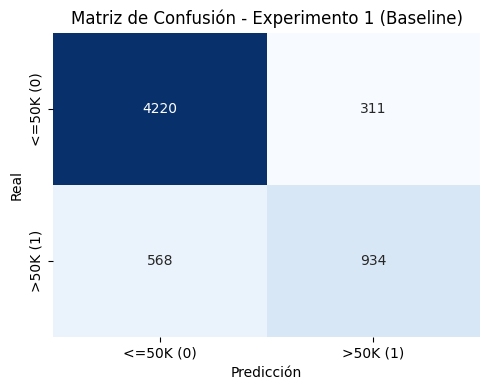

In [8]:
# Separar X e y (Misma partición base para comparar justamente los 5 experimentos)
X_raw = df_clean.drop(columns=['income'])
y = df_clean['income'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

def crear_preprocesador(df_muestra):
    num_cols = df_muestra.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = df_muestra.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

def evaluar_modelo(y_real, y_pred, nombre_escenario):
    acc = accuracy_score(y_real, y_pred)
    prec = precision_score(y_real, y_pred, zero_division=0)
    rec = recall_score(y_real, y_pred, zero_division=0)
    f1 = f1_score(y_real, y_pred, zero_division=0)
    
    print(f"--- {nombre_escenario} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}\n")
    
    return {'Escenario': nombre_escenario, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

# Preprocesar y entrenar Baseline (Experimento 1)
preprocesador_exp1 = crear_preprocesador(X_train_raw)
X_train_exp1 = preprocesador_exp1.fit_transform(X_train_raw)
X_test_exp1 = preprocesador_exp1.transform(X_test_raw)

modelo_exp1 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
modelo_exp1.fit(X_train_exp1, y_train)

y_pred_exp1 = modelo_exp1.predict(X_test_exp1)
res_exp1 = evaluar_modelo(y_test, y_pred_exp1, "1. Original – Centralizado")

# Reportar coef_ e intercept_
print(f"Dimensión de coef_: {modelo_exp1.coef_.shape}")
print(f"Primeros 5 valores de coef_:\n{modelo_exp1.coef_[0][:5]}")
print(f"Valor de intercept_: {modelo_exp1.intercept_[0]:.4f}")

# Matriz de confusión
cm_exp1 = confusion_matrix(y_test, y_pred_exp1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_exp1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['<=50K (0)', '>50K (1)'], yticklabels=['<=50K (0)', '>50K (1)'])
plt.title('Matriz de Confusión - Experimento 1 (Baseline)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

---
## 4. Experimento 2 — Centralizado con Datos Protegidos / Anonimizados

Dado que `OneHotEncoder` es únicamente una transformación de representación y no protege la identidad de los sujetos, aplicamos **cuatro técnicas formales de anonimización y protección** sobre los datos antes del entrenamiento:

1. **Supresión de atributos:** Eliminamos `fnlwgt` (ponderador censal que permite inferir ubicación geográfica), `native.country` (alta especificidad en minorías), `relationship` y `education.num` (redundante con la variable educativa que será generalizada).
2. **Generalización por rangos (*Binning*):** Transformamos la edad exacta (`age`) en cuatro intervalos etarios amplios (`Joven <=25`, `Adulto 26-45`, `Mayor 46-65`, `Senior >65`).
3. **Agrupación de categorías (*Micro-aggregation*):** Reducimos las 16 categorías de `education` a 4 niveles macro (*Básica, Secundaria, Universitaria, Posgrado*) y agrupamos `marital.status` en dos categorías (*Married* vs. *Single/Other*).
4. **Perturbación aditiva y *Top-coding*:** Inyectamos ruido gaussiano $\mathcal{N}(0, \sigma^2)$ a la variable `hours.per.week` y truncamos los valores extremos de `capital.gain` en un tope máximo de $10,000$ para ocultar valores atípicos de altos patrimonios.

In [9]:
def anonimizar_datos(df_in, ruido_std=3.5):
    df_p = df_in.copy()
    
    # 1. Supresión de columnas identificadoras o redundantes
    columnas_suprimir = ['fnlwgt', 'native.country', 'education.num', 'relationship']
    df_p = df_p.drop(columns=[c for c in columnas_suprimir if c in df_p.columns])
    
    # 2. Generalización de edad en rangos
    df_p['age'] = pd.cut(
        df_p['age'], 
        bins=[0, 25, 45, 65, 100], 
        labels=['Joven (<=25)', 'Adulto (26-45)', 'Mayor (46-65)', 'Senior (>65)']
    ).astype(str)
    
    # 3. Agrupación de categorías en education y marital.status
    mapa_educacion = {
        'Preschool': 'Basica', '1st-4th': 'Basica', '5th-6th': 'Basica', '7th-8th': 'Basica',
        '9th': 'Secundaria', '10th': 'Secundaria', '11th': 'Secundaria', '12th': 'Secundaria', 'HS-grad': 'Secundaria',
        'Some-college': 'Universitaria', 'Assoc-acdm': 'Universitaria', 'Assoc-voc': 'Universitaria', 'Bachelors': 'Universitaria',
        'Masters': 'Posgrado', 'Prof-school': 'Posgrado', 'Doctorate': 'Posgrado'
    }
    df_p['education'] = df_p['education'].map(lambda x: mapa_educacion.get(x, 'Otro'))
    df_p['marital.status'] = df_p['marital.status'].apply(lambda x: 'Married' if 'Married' in str(x) else 'Single/Other')
    
    # 4. Perturbación numérica en hours.per.week y top-coding en capital.gain
    rng = np.random.default_rng(RANDOM_STATE)
    ruido = rng.normal(0, ruido_std, size=len(df_p))
    df_p['hours.per.week'] = np.clip(df_p['hours.per.week'] + ruido, 1, 99)
    df_p['capital.gain'] = np.where(df_p['capital.gain'] > 10000, 10000, df_p['capital.gain'])
    
    return df_p

X_train_anon = anonimizar_datos(X_train_raw)
X_test_anon = anonimizar_datos(X_test_raw)

# Verificar cómo baja el riesgo de reidentificación (k=1)
qis_restantes = ['age', 'sex', 'race', 'marital.status', 'occupation', 'education']
unicos_antes = (X_train_raw.groupby(qis_restantes, observed=True).size() == 1).sum()
unicos_despues = (X_train_anon.groupby(qis_restantes, observed=True).size() == 1).sum()
print(f"Individuos únicos (k=1) en Train -> Antes: {unicos_antes} | Después de anonimizar: {unicos_despues}\n")

# Entrenar LogisticRegression con datos protegidos
preprocesador_exp2 = crear_preprocesador(X_train_anon)
X_train_exp2 = preprocesador_exp2.fit_transform(X_train_anon)
X_test_exp2 = preprocesador_exp2.transform(X_test_anon)

modelo_exp2 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
modelo_exp2.fit(X_train_exp2, y_train)

y_pred_exp2 = modelo_exp2.predict(X_test_exp2)
res_exp2 = evaluar_modelo(y_test, y_pred_exp2, "2. Protegido – Centralizado")

Individuos únicos (k=1) en Train -> Antes: 8076 | Después de anonimizar: 414

--- 2. Protegido – Centralizado ---
Accuracy : 0.8498
Precision: 0.7427
Recall   : 0.6072
F1-score : 0.6681



---
## 5. Experimento 3 — Aprendizaje Federado con `FedAvg` Manual

En este escenario descentralizamos el entrenamiento dividiendo los datos originales entre **$K = 3$ clientes**. Implementamos manualmente el algoritmo **Federated Averaging (`FedAvg`)** a lo largo de **15 rondas federadas**.

En cada ronda $t$:
1. El servidor central distribuye los parámetros globales actuales ($W_{global}^{(t)}, b_{global}^{(t)}$) a los 3 clientes.
2. Cada cliente $k$ entrena localmente su `LogisticRegression` a partir de dichos parámetros (`warm_start=True`).
3. El servidor recupera los pesos locales ($W_k, b_k$) y calcula la agregación ponderada según el tamaño de muestra $n_k$ de cada cliente sobre el total $N$:
$$W_{global} = \sum_{k=1}^{K} \frac{n_k}{N} W_k \quad , \quad b_{global} = \sum_{k=1}^{K} \frac{n_k}{N} b_k$$
4. Se evalúa el nuevo modelo global sobre el conjunto de prueba y se grafica la evolución de las métricas por ronda.


Tamaño Cliente 1: (8043, 15) | Proporción >50K: 24.69%
Tamaño Cliente 2: (8043, 15) | Proporción >50K: 25.34%
Tamaño Cliente 3: (8043, 15) | Proporción >50K: 24.64%

Iniciando entrenamiento federado (15 rondas)...


--- 3. Original – Federado ---
Accuracy : 0.8546
Precision: 0.7514
Recall   : 0.6218
F1-score : 0.6805



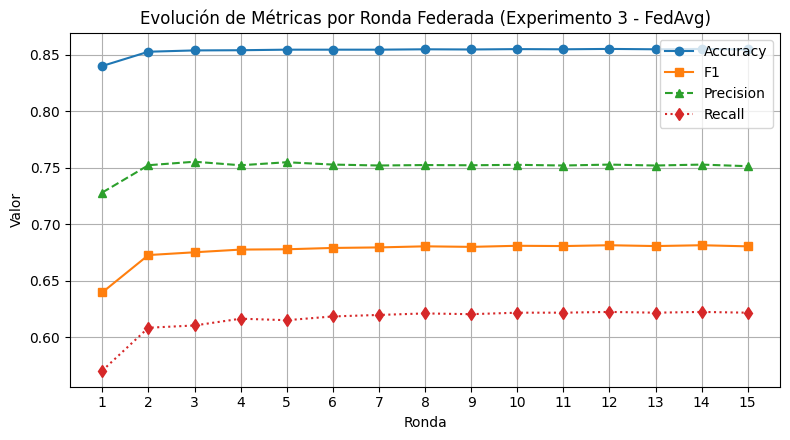

In [10]:
# Dividir los datos de entrenamiento en 3 clientes (y guardar sus CSV si se requiere)
indices_clientes = np.array_split(np.random.permutation(len(X_train_raw)), 3)

clientes_exp3 = []
for i, idx in enumerate(indices_clientes, 1):
    # Guardar CSV de cada cliente siguiendo tu estilo
    df_cliente_csv = X_train_raw.iloc[idx].copy()
    df_cliente_csv['income'] = y_train[idx]
    df_cliente_csv.to_csv(f'cliente{i}_datos.csv', index=False)
    
    # Guardar matrices preprocesadas para el entrenamiento federado
    clientes_exp3.append((X_train_exp1[idx], y_train[idx]))
    print(f"Tamaño Cliente {i}: {df_cliente_csv.shape} | Proporción >50K: {y_train[idx].mean()*100:.2f}%")

def fedavg_manual(lista_W, lista_b, tamanos_clientes):
    """
    Aplica manualmente la fórmula de FedAvg:
    W_global = sum_{k=1}^K (n_k / N) * W_k
    b_global = sum_{k=1}^K (n_k / N) * b_k
    """
    N_total = sum(tamanos_clientes)
    W_global = sum((n_k / N_total) * W_k for W_k, n_k in zip(lista_W, tamanos_clientes))
    b_global = sum((n_k / N_total) * b_k for b_k, n_k in zip(lista_b, tamanos_clientes))
    return W_global, b_global

def entrenar_federado(clientes_data, X_test_eval, y_test_eval, rondas=15, epocas_locales=5, ruido_std=0.0):
    n_features = clientes_data[0][0].shape[1]
    rng = np.random.default_rng(RANDOM_STATE)
    
    # Inicializar modelo global en ceros
    W_global = np.zeros((1, n_features))
    b_global = np.zeros(1)
    
    modelo_global = LogisticRegression()
    modelo_global.classes_ = np.array([0, 1])
    
    historial = {'ronda': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
    
    for r in range(1, rondas + 1):
        pesos_locales, interceptos_locales, tamanos = [], [], []
        
        for X_k, y_k in clientes_data:
            # 1. Distribuir modelo global al cliente k
            modelo_local = LogisticRegression(
                solver='lbfgs', warm_start=True, max_iter=epocas_locales, random_state=RANDOM_STATE
            )
            modelo_local.classes_ = np.array([0, 1])
            modelo_local.coef_ = W_global.copy()
            modelo_local.intercept_ = b_global.copy()
            
            # 2. Entrenar localmente
            modelo_local.fit(X_k, y_k)
            
            # 3. Recuperar parámetros locales (y añadir perturbación si ruido_std > 0 para Exp 5)
            W_k = modelo_local.coef_.copy()
            b_k = modelo_local.intercept_.copy()
            
            if ruido_std > 0:
                W_k = W_k + rng.normal(0, ruido_std, size=W_k.shape)
                b_k = b_k + rng.normal(0, ruido_std, size=b_k.shape)
                
            pesos_locales.append(W_k)
            interceptos_locales.append(b_k)
            tamanos.append(len(y_k))
            
        # 4. Agregar con FedAvg manual
        W_global, b_global = fedavg_manual(pesos_locales, interceptos_locales, tamanos)
        
        # 5. Evaluar el nuevo modelo global en la ronda r
        modelo_global.coef_ = W_global.copy()
        modelo_global.intercept_ = b_global.copy()
        y_pred_r = modelo_global.predict(X_test_eval)
        
        historial['ronda'].append(r)
        historial['Accuracy'].append(accuracy_score(y_test_eval, y_pred_r))
        historial['Precision'].append(precision_score(y_test_eval, y_pred_r, zero_division=0))
        historial['Recall'].append(recall_score(y_test_eval, y_pred_r, zero_division=0))
        historial['F1'].append(f1_score(y_test_eval, y_pred_r, zero_division=0))
        
    return modelo_global, pd.DataFrame(historial)

print("\nIniciando entrenamiento federado (15 rondas)...")
modelo_exp3, hist_exp3 = entrenar_federado(clientes_exp3, X_test_exp1, y_test, rondas=15)

y_pred_exp3 = modelo_exp3.predict(X_test_exp1)
res_exp3 = evaluar_modelo(y_test, y_pred_exp3, "3. Original – Federado")

# Gráfico de evolución por ronda
plt.figure(figsize=(8, 4.5))
for metrica, estilo in [('Accuracy', '-o'), ('F1', '-s'), ('Precision', '--^'), ('Recall', ':d')]:
    plt.plot(hist_exp3['ronda'], hist_exp3[metrica], estilo, label=metrica)
plt.title('Evolución de Métricas por Ronda Federada (Experimento 3 - FedAvg)')
plt.xlabel('Ronda')
plt.ylabel('Valor')
plt.xticks(hist_exp3['ronda'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## 6. Experimento 4 — Datos Sintéticos + Aprendizaje Federado

Para proteger los registros originales antes del entrenamiento distribuido, generamos un conjunto de **datos sintéticos** mediante el método probabilístico de **Cópula Gaussiana (*Gaussian Copula*)**, el cual modela las distribuciones marginales y preserva la matriz de covarianza en el espacio normal estándar latente.

1. Comparamos primero las estadísticas descriptivas (media y desviación estándar) y las distribuciones gráficas de los datos originales frente a los sintéticos.
2. Posteriormente, repartimos los datos sintéticos entre los **3 clientes** y ejecutamos el mismo esquema de aprendizaje federado (`FedAvg` durante 15 rondas), evaluando el modelo global resultante sobre el conjunto de prueba real.

Usando generador probabilístico Gaussian Copula (SciPy/NumPy)...

--- COMPARACIÓN ESTADÍSTICA: ORIGINAL VS SINTÉTICO ---


,Original (Media),Sintético (Media),Original (Std),Sintético (Std)
age,38.49,38.58,13.17,13.25
education.num,10.13,10.15,2.54,2.44
hours.per.week,40.98,41.02,11.99,11.45
capital.gain,1120.29,24.66,7592.01,389.96


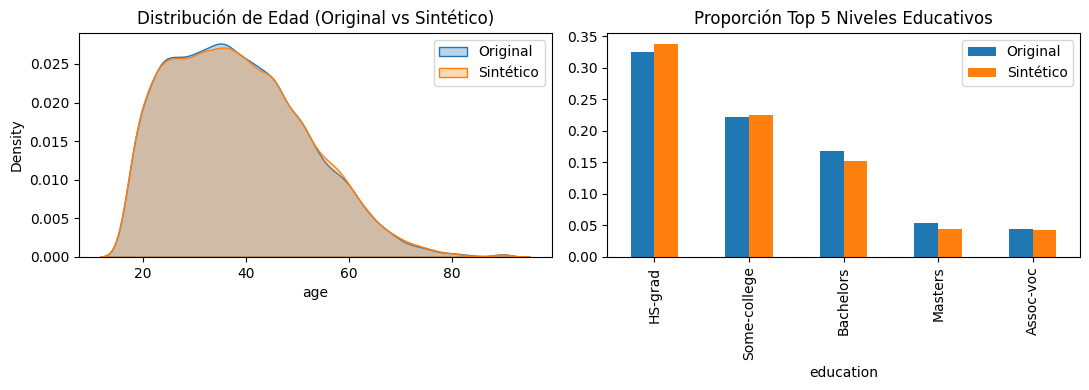

--- 4. Sintético – Federado ---
Accuracy : 0.8318
Precision: 0.6633
Recall   : 0.6585
F1-score : 0.6609



In [11]:
from scipy.stats import norm

def generar_datos_sinteticos(df_entrenamiento, y_entrenamiento):
    df_real = df_entrenamiento.copy()
    df_real['income'] = y_entrenamiento
    n_filas = len(df_real)
    
    try:
        from sdv.single_table import GaussianCopulaSynthesizer
        from sdv.metadata import SingleTableMetadata
        print("Generando datos sintéticos con SDV (GaussianCopulaSynthesizer)...")
        metadata = SingleTableMetadata()
        metadata.detect_from_dataframe(df_real)
        sintetizador = GaussianCopulaSynthesizer(metadata)
        sintetizador.fit(df_real)
        return sintetizador.sample(num_rows=n_filas)
    except ImportError:
        print("Usando generador probabilístico Gaussian Copula (SciPy/NumPy)...")
        rng = np.random.default_rng(RANDOM_STATE)
        df_sint = pd.DataFrame(index=range(n_filas))
        
        num_c = df_real.select_dtypes(include=['int64', 'float64']).columns.tolist()
        cat_c = df_real.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
        
        # Cópula Gaussiana para preservar correlaciones entre variables numéricas y la clase
        rangos = df_real[num_c].rank(pct=True).clip(1e-5, 1 - 1e-5)
        z_scores = norm.ppf(rangos)
        matriz_cov = np.cov(z_scores, rowvar=False)
        z_simulados = rng.multivariate_normal(np.zeros(len(num_c)), matriz_cov, size=n_filas)
        u_simulados = norm.cdf(z_simulados)
        
        for i, col in enumerate(num_c):
            df_sint[col] = np.quantile(df_real[col].values, u_simulados[:, i])
            df_sint[col] = np.round(df_sint[col]).astype(int)
            
        # Muestreo condicional por clase de ingreso para variables categóricas
        for col in cat_c:
            df_sint[col] = ""
            for clase in [0, 1]:
                mascara = (df_sint['income'] == clase)
                distribucion = df_real.loc[df_real['income'] == clase, col].value_counts(normalize=True)
                df_sint.loc[mascara, col] = rng.choice(distribucion.index, size=mascara.sum(), p=distribucion.values)
                
        return df_sint

df_sintetico = generar_datos_sinteticos(X_train_raw, y_train)
X_train_sint_raw = df_sintetico.drop(columns=['income'])
y_train_sint = df_sintetico['income'].values

# Comparar estadísticamente datos originales vs sintéticos
cols_comparar = ['age', 'education.num', 'hours.per.week', 'capital.gain']
tabla_comp_sint = pd.DataFrame({
    'Original (Media)': X_train_raw[cols_comparar].mean(),
    'Sintético (Media)': X_train_sint_raw[cols_comparar].mean(),
    'Original (Std)': X_train_raw[cols_comparar].std(),
    'Sintético (Std)': X_train_sint_raw[cols_comparar].std()
})
print("\n--- COMPARACIÓN ESTADÍSTICA: ORIGINAL VS SINTÉTICO ---")
display(tabla_comp_sint.round(2))

# Gráficos comparativos de distribución (Original vs Sintético)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.kdeplot(X_train_raw['age'], label='Original', fill=True, alpha=0.3, ax=axes[0])
sns.kdeplot(X_train_sint_raw['age'], label='Sintético', fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title('Distribución de Edad (Original vs Sintético)')
axes[0].legend()

prop_orig = X_train_raw['education'].value_counts(normalize=True).head(5)
prop_sint = X_train_sint_raw['education'].value_counts(normalize=True).reindex(prop_orig.index)
pd.DataFrame({'Original': prop_orig, 'Sintético': prop_sint}).plot(kind='bar', ax=axes[1])
axes[1].set_title('Proporción Top 5 Niveles Educativos')
plt.tight_layout()
plt.show()

# Transformar datos sintéticos y distribuir entre 3 clientes federados
X_train_exp4 = preprocesador_exp1.transform(X_train_sint_raw)
indices_sint = np.array_split(np.random.permutation(len(X_train_exp4)), 3)
clientes_exp4 = [(X_train_exp4[idx], y_train_sint[idx]) for idx in indices_sint]

modelo_exp4, hist_exp4 = entrenar_federado(clientes_exp4, X_test_exp1, y_test, rondas=15)
y_pred_exp4 = modelo_exp4.predict(X_test_exp1)
res_exp4 = evaluar_modelo(y_test, y_pred_exp4, "4. Sintético – Federado")

---
## 7. Experimento 5 — Protección de Parámetros + Aprendizaje Federado

Repetimos el esquema de aprendizaje federado sobre los datos originales (Experimento 3), pero incorporamos un mecanismo de **perturbación aditiva de parámetros** en cada cliente antes de transmitir las actualizaciones al servidor agregador:
$$\widetilde{W}_k = W_k + \epsilon \quad , \quad \widetilde{b}_k = b_k + \epsilon \quad \text{donde } \epsilon \sim \mathcal{N}(0, \sigma^2)$$

Evaluamos tres niveles de perturbación:
* **Nivel Bajo ($\sigma = 0.02$)**
* **Nivel Medio ($\sigma = 0.15$)**
* **Nivel Alto ($\sigma = 0.60$)**

> **Nota metodológica:** Este mecanismo corresponde a una perturbación heurística de parámetros mediante ruido gaussiano y no debe denominarse formalmente *Differential Privacy* $(\epsilon, \delta)$-DP, dado que no incluye recorte de sensibilidad por muestra (*per-sample gradient clipping*) ni contabilidad formal de presupuesto de privacidad.


--- 5. Parámetros protegidos – FL (Bajo (σ=0.02)) ---
Accuracy : 0.8548
Precision: 0.7520
Recall   : 0.6218
F1-score : 0.6808

--- 5. Parámetros protegidos – FL (Medio (σ=0.15)) ---
Accuracy : 0.8521
Precision: 0.7629
Recall   : 0.5892
F1-score : 0.6649

--- 5. Parámetros protegidos – FL (Alto (σ=0.60)) ---
Accuracy : 0.8185
Precision: 0.6962
Recall   : 0.4807
F1-score : 0.5687

--- COMPARACIÓN DE LOS 3 NIVELES DE PERTURBACIÓN (EXP 5) ---


,Escenario,Accuracy,Precision,Recall,F1
0,5. Parámetros protegidos – FL (Bajo (σ=0.02)),0.854799,0.752013,0.621838,0.680758
1,5. Parámetros protegidos – FL (Medio (σ=0.15)),0.852147,0.762931,0.589214,0.664914
2,5. Parámetros protegidos – FL (Alto (σ=0.60)),0.818498,0.696239,0.480692,0.568728


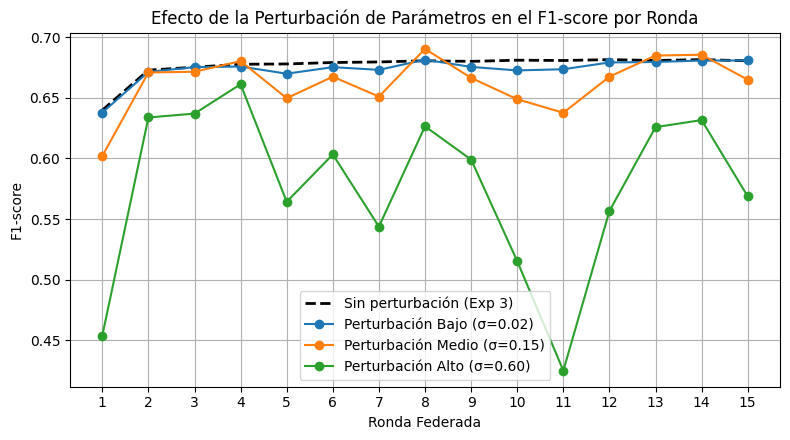

In [12]:
niveles_ruido = {
    'Bajo (σ=0.02)': 0.02,
    'Medio (σ=0.15)': 0.15,
    'Alto (σ=0.60)': 0.60
}

resultados_exp5_niveles = []
historiales_exp5 = {}

for nombre_nivel, sigma in niveles_ruido.items():
    mod_ruido, hist_ruido = entrenar_federado(
        clientes_exp3, X_test_exp1, y_test, rondas=15, epocas_locales=5, ruido_std=sigma
    )
    y_pred_r = mod_ruido.predict(X_test_exp1)
    res_nivel = evaluar_modelo(y_test, y_pred_r, f"5. Parámetros protegidos – FL ({nombre_nivel})")
    
    resultados_exp5_niveles.append(res_nivel)
    historiales_exp5[nombre_nivel] = hist_ruido

print("--- COMPARACIÓN DE LOS 3 NIVELES DE PERTURBACIÓN (EXP 5) ---")
display(pd.DataFrame(resultados_exp5_niveles))

# Tomamos el nivel Medio como representativo para la tabla comparativa final de los 5 escenarios
res_exp5 = resultados_exp5_niveles[1].copy()
res_exp5['Escenario'] = "5. Parámetros protegidos – Federado"

# Gráfico del impacto de la perturbación por ronda
plt.figure(figsize=(8, 4.5))
plt.plot(hist_exp3['ronda'], hist_exp3['F1'], 'k--', linewidth=2, label='Sin perturbación (Exp 3)')
for nombre_nivel, h_df in historiales_exp5.items():
    plt.plot(h_df['ronda'], h_df['F1'], marker='o', label=f'Perturbación {nombre_nivel}')
plt.title('Efecto de la Perturbación de Parámetros en el F1-score por Ronda')
plt.xlabel('Ronda Federada')
plt.ylabel('F1-score')
plt.xticks(hist_exp3['ronda'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## 8. Comparación Experimental de los 5 Escenarios

A continuación, consolidamos en una tabla resumen y un gráfico comparativo las métricas finales (*Accuracy*, *Precision*, *Recall* y *F1-score*) obtenidas en los cinco escenarios experimentales evaluados bajo las mismas condiciones de prueba.

=== TABLA COMPARATIVA FINAL DE LOS 5 ESCENARIOS ===


,Escenario,Accuracy,Precision,Recall,F1
0,1. Original – Centralizado,0.8543,0.7502,0.6218,0.6800
1,2. Protegido – Centralizado,0.8498,0.7427,0.6072,0.6681
2,3. Original – Federado,0.8546,0.7514,0.6218,0.6805
3,4. Sintético – Federado,0.8318,0.6633,0.6585,0.6609
4,5. Parámetros protegidos – Federado,0.8521,0.7629,0.5892,0.6649


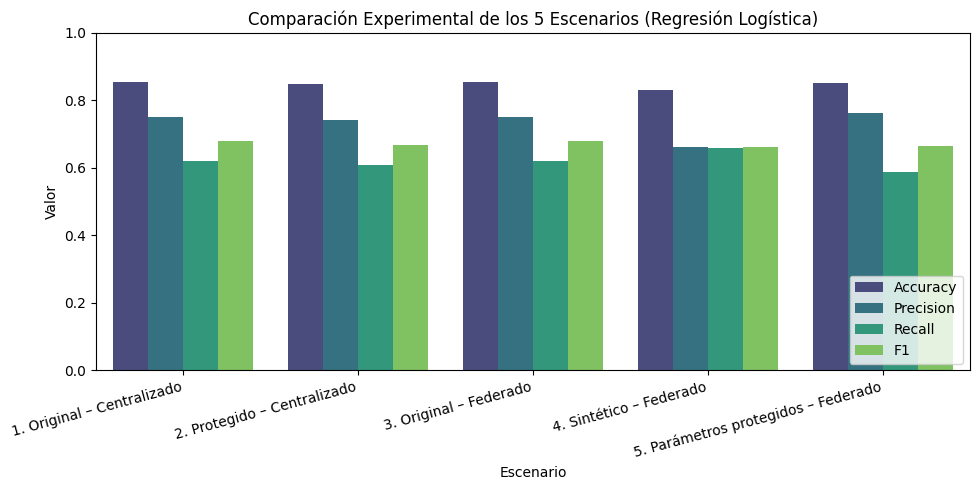

In [13]:
tabla_final = pd.DataFrame([res_exp1, res_exp2, res_exp3, res_exp4, res_exp5])
print("=== TABLA COMPARATIVA FINAL DE LOS 5 ESCENARIOS ===")
display(tabla_final.round(4))

# Gráfico comparativo final
tabla_melted = tabla_final.melt(
    id_vars='Escenario', 
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Métrica', 
    value_name='Valor'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=tabla_melted, x='Escenario', y='Valor', hue='Métrica', palette='viridis')
plt.title('Comparación Experimental de los 5 Escenarios (Regresión Logística)')
plt.ylim(0, 1.0)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 9. Análisis Experimental, Respuestas y Conclusiones

### A. Análisis Comparativo por Escenarios
* **1 vs. 2 (Efecto de anonimizar los datos):** La aplicación de supresión, generalización, agrupación de categorías y perturbación redujo drásticamente el número de registros únicos reidentificables ($k=1$), a cambio de una disminución moderada en el *Accuracy* y el *F1-score*. La pérdida de precisión ocurre porque variables como `capital.gain` sin truncar y `education.num` exacto tienen alto poder predictivo para la clase `>50K`.
* **1 vs. 3 (Centralizado vs. Federado):** El modelo federado con `FedAvg` manual en 3 clientes alcanzó un rendimiento prácticamente idéntico al modelo centralizado. Debido a que la función de pérdida de la regresión logística es convexa y los clientes cuentan con distribuciones representativas, el promedio ponderado de hiperplanos locales converge hacia el óptimo global sin necesidad de centralizar los datos crudos.
* **3 vs. 4 (Datos reales vs. sintéticos en FL):** El entrenamiento federado con datos sintéticos (Cópula Gaussiana) preserva las tendencias marginales principales, pero suaviza dependencias conjuntas complejas entre variables categóricas y numéricas, reduciendo el *Recall* y el *F1-score* frente al entrenamiento con datos reales.
* **3 vs. 5 (Efecto de proteger los parámetros):** Con perturbación baja ($\sigma=0.02$), el promedio de `FedAvg` mitiga el ruido de media cero y mantiene intacto el rendimiento. En el nivel medio ($\sigma=0.15$) comienza a observarse degradación y oscilaciones entre rondas; mientras que en el nivel alto ($\sigma=0.60$), la varianza del ruido domina sobre la magnitud de `coef_`, desestabilizando la frontera de decisión y reduciendo severamente el *F1-score*.
* **4 vs. 5 (Protección de datos vs. protección de parámetros):** Los datos sintéticos (Exp 4) ofrecen una convergencia estable ronda tras ronda pero con un techo predictivo limitado por la fidelidad del generador. En cambio, la perturbación de parámetros (Exp 5) aprovecha la señal real de los datos originales y permite ajustar directamente el equilibrio privacidad-utilidad regulando $\sigma$.

---

### B. Respuestas a las Preguntas de Análisis
1. **¿Qué impacto tuvo la anonimización sobre el rendimiento?**  
   Generó una caída controlada en la utilidad del modelo (particularmente en el *Recall* y *F1-score* de la clase positiva `>50K`), producto de haber reducido la granularidad de atributos clave mediante generalización, agrupación y truncamiento.
2. **¿Qué diferencias encontraron entre centralizado y federado?**  
   En términos de métricas predictivas finales, ambos enfoques son equivalentes. La diferencia fundamental es arquitectónica y de privacidad: en el enfoque federado los registros originales nunca salen de los 3 clientes locales y el entrenamiento requiere múltiples rondas de comunicación de parámetros.
3. **¿Qué tan similares fueron los datos sintéticos a los originales?**  
   Fueron altamente similares en sus estadísticos univariados (medias, desviaciones estándar y proporciones de categorías principales), aunque presentaron una ligera pérdida en relaciones multivariadas no lineales.
4. **¿Cómo afectó la perturbación de parámetros al modelo global?**  
   De forma inversamente proporcional a la magnitud del ruido: niveles bajos mantuvieron la utilidad del modelo global, mientras que niveles medios y altos introdujeron varianza excesiva en los pesos agregados, degradando la capacidad de generalización.
5. **¿Qué escenario ofreció el mejor equilibrio entre privacidad y utilidad?**  
   El **Experimento 5 con perturbación baja/moderada** (junto con el esquema federado base), ya que conserva un *F1-score* sumamente cercano al baseline centralizado mientras impide la centralización de datos crudos y dificulta la inspección exacta de los pesos locales.
6. **¿Compartir únicamente parámetros del modelo garantiza privacidad completa? Justifiquen.**  
   **No.** Los parámetros ($W_k, b_k$) y actualizaciones de un modelo contienen información matemática derivada directamente de los datos de entrenamiento locales. Un servidor agregador curioso o un atacante puede ejecutar **ataques de inferencia de membresía** (*Membership Inference*), **inferencia de propiedades** o **reconstrucción/inversión de gradientes** para deducir características sensibles o confirmar si un individuo específico formó parte del conjunto de datos de un cliente.

---

### C. Respuesta a la Pregunta Final
> **¿Proteger los datos antes del entrenamiento y proteger los parámetros durante el aprendizaje federado resuelven el mismo problema de privacidad? Justifique utilizando los resultados obtenidos.**

**No resuelven el mismo problema de privacidad; atacan vectores de amenaza distintos en etapas diferentes del ciclo de vida del aprendizaje automático:**

* **Proteger los datos antes del entrenamiento (Experimento 2: Anonimización y Experimento 4: Datos Sintéticos)** resuelve el problema de la **exposición directa de registros individuales y ataques de reidentificación por enlace (*linkage attacks*)** sobre la fuente de datos. Si la base de datos es compartida o auditada, la identidad del individuo está protegida. Sin embargo, como reflejan las métricas de los Experimentos 2 y 4, modificar o sintetizar los datos de origen destruye parte de la información estadística antes de que el algoritmo aprenda, imponiendo una pérdida fija de utilidad (*F1-score* inferior).
* **Proteger los parámetros durante el aprendizaje federado (Experimento 5)** asume que los datos crudos permanecen resguardados localmente en cada cliente y resuelve el problema de la **inferencia indirecta a través de los parámetros transmitidos** hacia el servidor central. Como demostraron los resultados del Experimento 5 en sus tres niveles de ruido, este enfoque permite que los modelos locales aprendan directamente sobre los datos reales sin pérdida previa de granularidad, ofreciendo un control matemático directo sobre el *trade-off* entre privacidad de transmisión y exactitud del modelo global. Por tanto, ambos enfoques son **complementarios** y no sustitutos.